In [45]:
# !pip install -U scikit-learn
# !pip install acopy

In [102]:
import os
import time
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
import community
import graph_tool.all as gt
import itertools
import acopy
from sklearn.metrics import adjusted_rand_score

# Question 2

## (b)

In [77]:
folder = '../../data/tsp/'
gml_files = [f for f in os.listdir(folder) if f.endswith(".gml")]
for gml_file in gml_files:
    path = os.path.join(folder, gml_file)
    G = nx.read_gml(path)
    print(f'{gml_file} has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges')

berlin52.gml has 52 nodes and 2652 edges
brazil58.gml has 58 nodes and 3306 edges
brg180.gml has 180 nodes and 32220 edges
gr229.gml has 229 nodes and 52212 edges
pr439.gml has 439 nodes and 192282 edges


## (c)

In [87]:
graph_names = ['g_berlin', 'g_brazil', 'g_brg', 'g_gr', 'g_pr']
graphs = {}
for gml_file, name in zip(gml_files, graph_names):
    path = os.path.join(folder, gml_file)
    G = nx.read_gml(path)

    for u, v, attrs in G.edges(data=True):
        if 'cost' in attrs:
            attrs['weight'] = attrs.pop('cost')

    graphs[name] = G.copy()

In [88]:
solver = acopy.Solver(rho=.03, q=1)
colony = acopy.Colony(alpha=1, beta=3)

In [100]:
# test
tour = solver.solve(graphs['g_berlin'], colony, limit=10)
tour.cost

8790.920972565023

## (e)

In [107]:
graph_sizes = []
runtimes = []

for name, g in graphs.items():
    print(g)
    g_runtime = []
    for _ in range(3):
        start_time = time.time()
        tour = solver.solve(g, colony, limit=1)
        end_time = time.time()
        g_runtime.append(end_time - start_time)

    avg_runtime = np.mean(g_runtime)
    runtimes.append(avg_runtime)
    graph_sizes.append(g.number_of_nodes())
    print(f'{name}: number of nodes: {g.number_of_nodes()}, average runtime: {avg_runtime:.3f}')

DiGraph with 52 nodes and 2652 edges
g_berlin: number of nodes: 52, average runtime: 0.224
DiGraph with 58 nodes and 3306 edges
g_brazil: number of nodes: 58, average runtime: 0.327
DiGraph with 180 nodes and 32220 edges
g_brg: number of nodes: 180, average runtime: 21.213
DiGraph with 229 nodes and 52212 edges
g_gr: number of nodes: 229, average runtime: 51.030
DiGraph with 439 nodes and 192282 edges
g_pr: number of nodes: 439, average runtime: 681.663


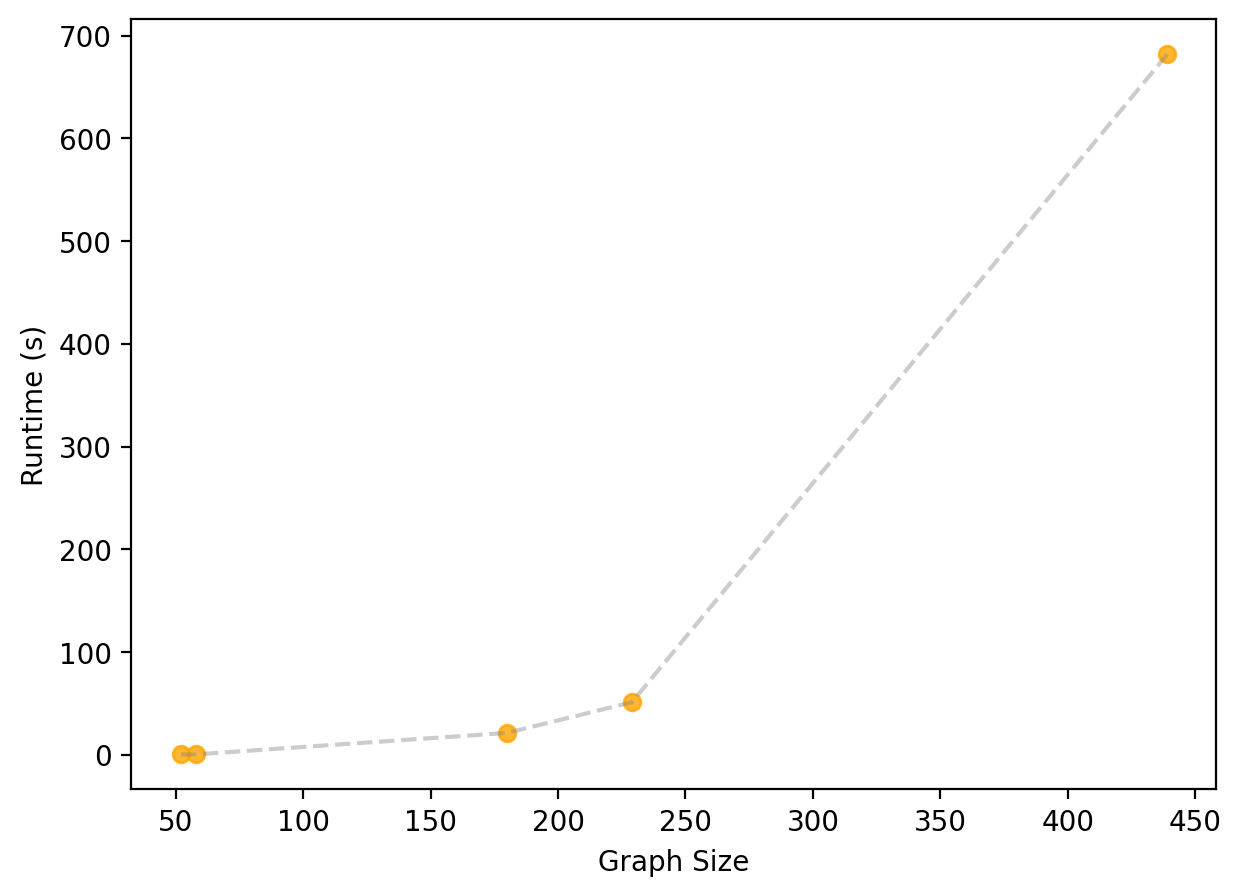

In [113]:
fig, ax = plt.subplots(1,1,figsize=(7,5),dpi=200)
ax.scatter(graph_sizes, runtimes, color='orange', alpha=0.8)
ax.plot(graph_sizes, runtimes, linestyle='--', color='gray', alpha=0.4)
plt.xlabel('Graph Size')
plt.ylabel('Runtime (s)')
plt.savefig('2e.png', dpi=425, bbox_inches='tight')
plt.show()

# Question 3

## (a)

In [48]:
# https://networkrepository.com/inf-openflights.php

with open('inf-openflights.edges','r') as fp:
    lines = fp.readlines()[2:]

G = nx.parse_edgelist(lines, nodetype=int)
print("Number of nodes: %d" % G.number_of_nodes())
print("Number of edges: %d" % G.number_of_edges())

# duplicated edges?

Number of nodes: 2939
Number of edges: 15677


In [49]:
# detect communities
partition = community.best_partition(G)

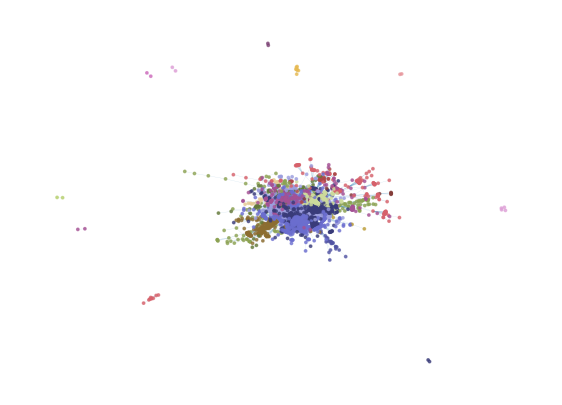

In [50]:
# visualize network
colors_sns = plt.cm.tab20b(np.linspace(0,1,len(np.unique(list(partition.values())))))
colors_nodes = [colors_sns[partition[node]] for node in G.nodes()]

fig, ax = plt.subplots(1,1,figsize=(7,5),dpi=100)
pos = nx.spring_layout(G)
nx.draw_networkx_edges(G, pos, width=0.2, edge_color='tab:blue', alpha=0.2)
nx.draw_networkx_nodes(G, pos, node_size=3, node_color=colors_nodes, alpha=0.7)
ax.set_axis_off()
plt.show()

In [51]:
# calculate modularity
community.modularity(partition, G)

0.6521224038594494

In [52]:
# number of communities
max(partition.values())

27

From the visualization, we can see a giant component. Let's check if using only the largest component helps detect the number of communities.

In [53]:
F = G.copy()
largest_cc = max(nx.connected_components(F), key=len)
gcc = G.subgraph(largest_cc).copy()

print("Number of gcc nodes: %d" % gcc.number_of_nodes())
print("Number of gcc edges: %d" % gcc.number_of_edges())

Number of gcc nodes: 2905
Number of gcc edges: 15645


In [54]:
# detect communities
gcc_partition = community.best_partition(gcc)

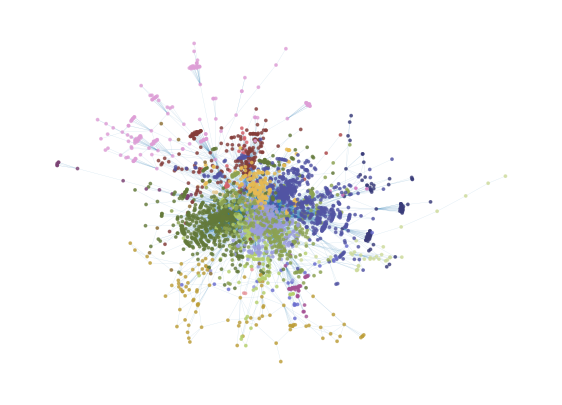

In [55]:
# visualize network
colors_sns = plt.cm.tab20b(np.linspace(0,1,len(np.unique(list(gcc_partition.values())))))
colors_nodes = [colors_sns[gcc_partition[node]] for node in gcc.nodes()]

fig, ax = plt.subplots(1,1,figsize=(7,5),dpi=100)
pos = nx.spring_layout(gcc)
nx.draw_networkx_edges(gcc, pos, width=0.2, edge_color='tab:blue', alpha=0.2)
nx.draw_networkx_nodes(gcc, pos, node_size=3, node_color=colors_nodes, alpha=0.7)
ax.set_axis_off()
plt.savefig('3a.png', dpi=425, bbox_inches='tight')
# plt.savefig('3a.pdf', dpi=425, bbox_inches='tight')
plt.show()

In [56]:
# calculate modularity
community.modularity(gcc_partition, gcc)

0.6489132570584503

In [57]:
# number of communities
max(gcc_partition.values())

20

In [58]:
# store the partition {node_id: community_id}
# the 'gcc_partition' is already a dictionary in the expected form

## (b)

In [59]:
# function from the class material

def nx2gt(nxG):
    """
    Converts a networkx graph to a graph-tool graph.
    """
    # Phase 0: Create a directed or undirected graph-tool Graph
    gtG = gt.Graph(directed=nxG.is_directed())

    # Add the Graph properties as "internal properties"
    for key, value in nxG.graph.items():
        # Convert the value and key into a type for graph-tool
        tname, value, key = get_prop_type(value, key)

        prop = gtG.new_graph_property(tname) # Create the PropertyMap
        gtG.graph_properties[key] = prop     # Set the PropertyMap
        gtG.graph_properties[key] = value    # Set the actual value

    # Phase 1: Add the vertex and edge property maps
    # Go through all nodes and edges and add seen properties
    # Add the node properties first
    nprops = set() # cache keys to only add properties once
    for node, data in nxG.nodes(data=True):

        # Go through all the properties if not seen and add them.
        for key, val in data.items():
            if key in nprops: continue # Skip properties already added

            # Convert the value and key into a type for graph-tool
            tname, _, key  = get_prop_type(val, key)

            prop = gtG.new_vertex_property(tname) # Create the PropertyMap
            gtG.vertex_properties[key] = prop     # Set the PropertyMap

            # Add the key to the already seen properties
            nprops.add(key)

    # Also add the node id: in NetworkX a node can be any hashable type, but
    # in graph-tool node are defined as indices. So we capture any strings
    # in a special PropertyMap called 'id' -- modify as needed!
    gtG.vertex_properties['id'] = gtG.new_vertex_property('string')

    # Add the edge properties second
    eprops = set() # cache keys to only add properties once
    for src, dst, data in nxG.edges(data=True):

        # Go through all the edge properties if not seen and add them.
        for key, val in data.items():
            if key in eprops: continue # Skip properties already added

            # Convert the value and key into a type for graph-tool
            tname, _, key = get_prop_type(val, key)

            prop = gtG.new_edge_property(tname) # Create the PropertyMap
            gtG.edge_properties[key] = prop     # Set the PropertyMap

            # Add the key to the already seen properties
            eprops.add(key)

    # Phase 2: Actually add all the nodes and vertices with their properties
    # Add the nodes
    vertices = {} # vertex mapping for tracking edges later
    for node, data in nxG.nodes(data=True):

        # Create the vertex and annotate for our edges later
        v = gtG.add_vertex()
        vertices[node] = v

        # Set the vertex properties, not forgetting the id property
        data['id'] = str(node)
        for key, value in data.items():
            gtG.vp[key][v] = value # vp is short for vertex_properties

    # Add the edges
    for src, dst, data in nxG.edges(data=True):

        # Look up the vertex structs from our vertices mapping and add edge.
        e = gtG.add_edge(vertices[src], vertices[dst])

        # Add the edge properties
        for key, value in data.items():
            gtG.ep[key][e] = value # ep is short for edge_properties

    # Done, finally!
    return gtG

In [60]:
gcc_gt = nx2gt(gcc)

In [61]:
# detect communities
# visualize network
# calculate modularity
# number of communities
# store the partition {node_id: community_id}

In [62]:
# detect communities
state = gt.minimize_blockmodel_dl(gcc_gt, state_args=dict(deg_corr=True))
communities = state.get_blocks()

# visualize network
pos = gt.sfdp_layout(gcc_gt)
state.draw(output="3b.png")

## Integration with matplotlib does not work as expected
# fig, ax = plt.subplots(1,1,figsize=(7,5),dpi=100) 
# a = gt.graph_draw(
#     gcc_gt, 
#     pos=pos, 
#     vertex_fill_color=communities,
#     mplfig=ax
# )
# ax.set_axis_off()
# a.fit_view(yflip=True)
# plt.savefig('3b.png', dpi=425, bbox_inches='tight')
# plt.savefig('3b.pdf', dpi=425, bbox_inches='tight')
# plt.show()

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x2b7b4a5b7d70, at 0x2b7b4a909910>

In [63]:
# calculate modularity
gt.modularity(gcc_gt, communities)

0.21187255257342194

In [64]:
# store the partition {node_id: community_id}
gt_gcc_partition = {int(v): communities[v] for v in gcc_gt.vertices()}

In [65]:
# number of communities
len(np.unique(list(gt_gcc_partition.values())))

182

## (c)

In [66]:
# degree-preserving randomization of original network
# For a randomized network, we use a configuration model
deg_seq = [d for n, d in gcc.degree()]
gcc_ran = nx.configuration_model(deg_seq)

print("Number of original gcc nodes: %d" % gcc.number_of_nodes())
print("Number of original gcc edges: %d" % gcc.number_of_edges())
print("Number of randomized gcc nodes: %d" % gcc_ran.number_of_nodes())
print("Number of randomized gcc edges: %d" % gcc_ran.number_of_edges())

Number of original gcc nodes: 2905
Number of original gcc edges: 15645
Number of randomized gcc nodes: 2905
Number of randomized gcc edges: 15645


In [67]:
# 1. detect communities
gcc_ran_partition = community.best_partition(gcc_ran)

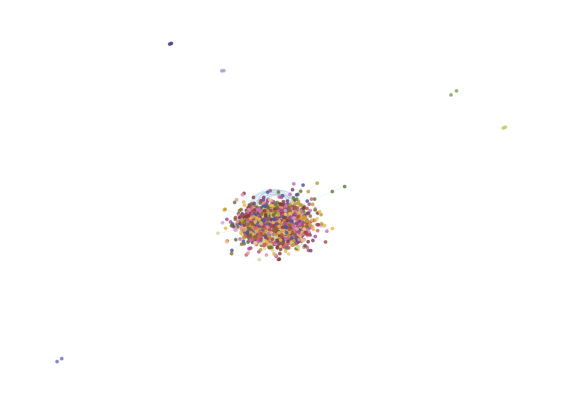

In [68]:
# 2. visualize network
colors_sns = plt.cm.tab20b(np.linspace(0,1,len(np.unique(list(gcc_ran_partition.values())))))
colors_nodes = [colors_sns[gcc_ran_partition[node]] for node in gcc_ran.nodes()]

fig, ax = plt.subplots(1,1,figsize=(7,5),dpi=100)
pos = nx.spring_layout(gcc_ran)
nx.draw_networkx_edges(gcc_ran, pos, width=0.2, edge_color='tab:blue', alpha=0.2)
nx.draw_networkx_nodes(gcc_ran, pos, node_size=3, node_color=colors_nodes, alpha=0.7)
ax.set_axis_off()
plt.savefig('3c.png', dpi=425, bbox_inches='tight')
# plt.savefig('3c.pdf', dpi=425, bbox_inches='tight')
plt.show()

In [69]:
# 3. calculate modularity
gcc_ran_m = community.modularity(gcc_ran_partition, gcc_ran)
print("Modularity of randomized network: %.3f" % gcc_ran_m)

# 4. number of communities
gcc_ran_num_of_com = max(gcc_ran_partition.values())
print("Number of communities of randomized network: %d" % gcc_ran_num_of_com)

# 5. store the partition {node_id: community_id}
# the 'partition' is already a dictionary in the expected form
first_five_items = dict(itertools.islice(gcc_ran_partition.items(), 5))
print("First 5 items of partition:", first_five_items)

Modularity of randomized network: 0.228
Number of communities of randomized network: 19
First 5 items of partition: {0: 8, 1: 1, 2: 4, 3: 15, 4: 4}


In [70]:
gt_gcc_ran = nx2gt(gcc_ran)

In [71]:
# 1. detect communities
state = gt.minimize_blockmodel_dl(gt_gcc_ran)
gcc_ran_communities = state.get_blocks()

# 2. visualize network
pos = gt.sfdp_layout(gt_gcc_ran)
# gt.graph_draw(gt_gcc_ran, pos=pos, vertex_fill_color=gcc_ran_communities)
state.draw(output="3d.png")

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x2b7afefc2ff0, at 0x2b7b4a8e9760>

In [72]:
# 3. calculate modularity
gt_gcc_ran_m = gt.modularity(gt_gcc_ran, gcc_ran_communities)
print("Modularity of gt network: %.3f" % gt_gcc_ran_m)

# 4. store the partition {node_id: community_id}
gt_gcc_ran_partition = {int(v): gcc_ran_communities[v] for v in gt_gcc_ran.vertices()}

# 5. number of communities
gt_gcc_ran_num_of_com = len(np.unique(list(gt_gcc_ran_partition.values())))
print("Number of communities of gt network: %d" % gt_gcc_ran_num_of_com)

Modularity of gt network: 0.000
Number of communities of gt network: 1


## (d)

In [73]:
# convert partitions to aligned label lists using the union of nodes
def partition_to_labels(partition):
    return [partition[node] for node in sorted(partition.keys())]

gcc_labels = partition_to_labels(gcc_partition)
gt_gcc_labels = partition_to_labels(gt_gcc_partition)
gcc_ran_labels = partition_to_labels(gcc_ran_partition)
gt_gcc_ran_labels = partition_to_labels(gt_gcc_ran_partition)

ari_1 = metrics.adjusted_rand_score(gcc_labels, gt_gcc_labels)
ari_2 = metrics.adjusted_rand_score(gcc_labels, gcc_ran_labels)
ari_3 = metrics.adjusted_rand_score(gt_gcc_labels, gt_gcc_ran_labels)
ari_4 = metrics.adjusted_rand_score(gcc_ran_labels, gt_gcc_ran_labels)

ari_results = {
    "ARI(gcc_partition, gt_gcc_partition)": ari_1,
    "ARI(gcc_partition, gcc_ran_partition)": ari_2,
    "ARI(gt_gcc_partition, gt_gcc_ran_partition)": ari_3,
    "ARI(gcc_ran_partition, gt_gcc_ran_partition)": ari_4,
}

for k, v in ari_results.items():
    print(f"{k}: {v:.3f}")

ARI(gcc_partition, gt_gcc_partition): 0.184
ARI(gcc_partition, gcc_ran_partition): 0.001
ARI(gt_gcc_partition, gt_gcc_ran_partition): 0.000
ARI(gcc_ran_partition, gt_gcc_ran_partition): 0.000
